# Lab 1 — Outlier Exploration

**Day 06 · Anomaly Detection · Cisco AI/ML Training**

---

## Goals

1. Load the credit card transaction dataset (**1,000** rows, **10** fraud).
2. Count **IQR outliers** in `amount` and `distance_from_home`.
3. Compare fraud vs legitimate transaction profiles.
4. Explain why rule-based outlier flags alone are insufficient for fraud.

> **Quick check:** **1000** rows · **10** fraud · mean fraud amount ≈ **234** · legit ≈ **43**

**Dataset:** `data/credit-card/credit_card_transactions.csv`

## Why this matters <!-- cisco-doc-enrich-2026 -->

Fraud is **rare and extreme** — outliers in amount or distance often flag cases rules miss.
Exploration precedes any supervised model.

```
legit transactions ...........  (tight cloud)
fraud *  *  (few, far from centroid / high amount)
```


## Outliers vs fraud

Fraudulent transactions often look like **outliers**, but not every outlier is fraud.

## Anomaly detection methods (course syllabus)

| Method | Type | This course |
|--------|------|-------------|
| IQR / rules | Statistical | **This lab** |
| LOF | Proximity | Day 6 Lab 4 |
| Random Forest | Ensemble supervised | Day 6 Lab 5 |

In [1]:
%matplotlib inline

from pathlib import Path

GH_ROOT = Path.cwd().resolve()
if GH_ROOT.name == "notebooks":
    GH_ROOT = GH_ROOT.parents[2]
elif (GH_ROOT.parent / "notebooks").is_dir() and (GH_ROOT.parents[1] / "requirements-student.txt").is_file():
    GH_ROOT = GH_ROOT.parents[1]
else:
    for parent in [GH_ROOT, *GH_ROOT.parents]:
        if (parent / "requirements-student.txt").is_file():
            GH_ROOT = parent
            break

# cisco-output-ready
print(f"Setup OK — repo root: {GH_ROOT}")


Setup OK — repo root: C:\25-Trainings\2-Confirmed\10-June-26-AI-ML-Cisco\GH


**Step 2** — run the cell below and read the printed summary. <!-- cisco-split-debug-2026 -->

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

df = pd.read_csv(GH_ROOT / "data" / "credit-card" / "credit_card_transactions.csv")

print("Lab 1 — Outlier exploration")
print(f"rows: {len(df)}")
print(f"fraud rows: {int(df['is_fraud'].sum())}")
print(f"fraud rate: {df['is_fraud'].mean():.4f}")
display(df.head(3))

Lab 1 — Outlier exploration
rows: 1000
fraud rows: 10
fraud rate: 0.0100


,transaction_id,timestamp,amount,merchant_category,distance_from_home,is_fraud
0,T0000001,2025-01-01T00:00:00Z,7.40,electronics,1.58,0
1,T0000002,2025-01-01T00:17:00Z,93.87,pharmacy,3.49,0
2,T0000003,2025-01-01T00:34:00Z,29.76,travel,10.80,0


## IQR outlier helper

In [3]:
def iqr_outlier_count(series: pd.Series) -> int:
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return int(((series < lower) | (series > upper)).sum())

def iqr_bounds(series: pd.Series) -> tuple[float, float]:
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

amount_outliers = iqr_outlier_count(df["amount"])
distance_outliers = iqr_outlier_count(df["distance_from_home"])

print(f"IQR outliers (amount): {amount_outliers}")
print(f"IQR outliers (distance): {distance_outliers}")



IQR outliers (amount): 58
IQR outliers (distance): 58


## Fraud vs legitimate means

In [4]:
legit_amount_mean = df.loc[df["is_fraud"] == 0, "amount"].mean()
fraud_amount_mean = df.loc[df["is_fraud"] == 1, "amount"].mean()
max_fraud_distance = df.loc[df["is_fraud"] == 1, "distance_from_home"].max()

print(f"mean amount (legit): {legit_amount_mean:.2f}")
print(f"mean amount (fraud): {fraud_amount_mean:.2f}")
print(f"max distance (fraud): {max_fraud_distance:.2f}")

mean amount (legit): 43.22
mean amount (fraud): 233.94
max distance (fraud): 51.72


**Step 2** — run the cell below and read the printed summary. <!-- cisco-split-debug-2026 -->

In [5]:
compare = pd.DataFrame({
    "group": ["legit", "fraud"],
    "mean_amount": [legit_amount_mean, fraud_amount_mean],
    "count": [(df["is_fraud"] == 0).sum(), (df["is_fraud"] == 1).sum()],
})
display(compare.round(2))

,group,mean_amount,count
0,legit,43.22,990
1,fraud,233.94,10


## Prediction outliers (course topic)




In [6]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

X_pred = df[["amount", "distance_from_home"]]
y_true = df["is_fraud"]

**Step 2** — run the cell below and read the printed summary. <!-- cisco-split-debug-2026 -->

In [7]:
clf = Pipeline(
    [
        ("scale", StandardScaler()),
        ("lr", LogisticRegression(max_iter=500, random_state=42)),
    ]
)
clf.fit(X_pred, y_true)
proba = clf.predict_proba(X_pred)[:, 1]
residual = np.abs(y_true.to_numpy() - proba)

# cisco-debug-summary
print("Model fit complete.")

Model fit complete.


**Step 3** — run the cell below and read the printed summary. <!-- cisco-split-debug-2026 -->

In [8]:
cutoff = float(np.quantile(residual, 0.99))
pred_outlier_mask = residual >= cutoff
n_pred_outliers = int(pred_outlier_mask.sum())
fraud_in_pred_outliers = int(df.loc[pred_outlier_mask, "is_fraud"].sum())

print(f"prediction-outlier threshold (99th pct |y - p|): {cutoff:.4f}")
print(f"flagged rows: {n_pred_outliers}")
print(f"fraud among flagged: {fraud_in_pred_outliers} / {int(y_true.sum())} total fraud")

prediction-outlier threshold (99th pct |y - p|): 0.1477
flagged rows: 10
fraud among flagged: 6 / 10 total fraud


## Visualize amount and distance

C:\Users\PC\AppData\Local\Temp\ipykernel_27488\974498555.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="is_fraud", y="amount", ax=axes[0], palette="Set2")
C:\Users\PC\AppData\Local\Temp\ipykernel_27488\974498555.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(["legit (0)", "fraud (1)"])
C:\Users\PC\AppData\Local\Temp\ipykernel_27488\974498555.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="is_fraud", y="distance_from_home", ax=axes[1], palette="Set2")


C:\Users\PC\AppData\Local\Temp\ipykernel_27488\974498555.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(["legit (0)", "fraud (1)"])


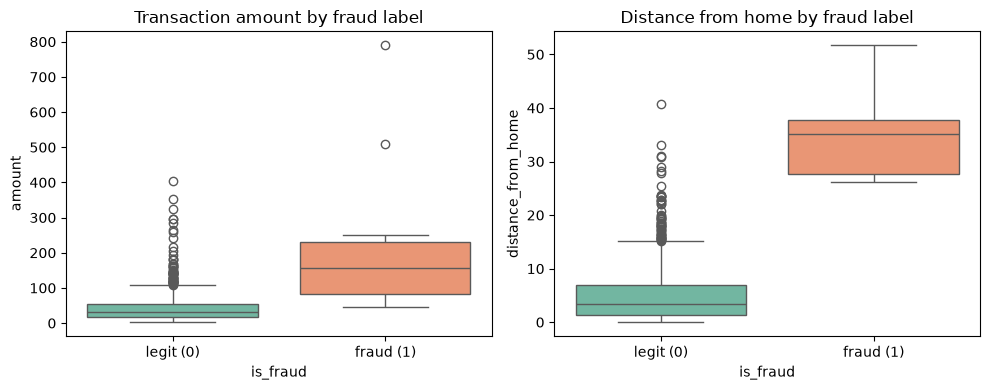

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.boxplot(data=df, x="is_fraud", y="amount", ax=axes[0], palette="Set2")
axes[0].set_title("Transaction amount by fraud label")
axes[0].set_xticklabels(["legit (0)", "fraud (1)"])

sns.boxplot(data=df, x="is_fraud", y="distance_from_home", ax=axes[1], palette="Set2")
axes[1].set_title("Distance from home by fraud label")
axes[1].set_xticklabels(["legit (0)", "fraud (1)"])

plt.tight_layout()
plt.show()


## Fraud transactions

In [10]:
fraud_df = df.loc[df["is_fraud"] == 1].sort_values("amount", ascending=False)
display(fraud_df[["amount", "distance_from_home", "merchant_category"]].round(2))


,amount,distance_from_home,merchant_category
337,790.20,37.32,online_retail
346,510.55,27.68,travel
696,249.70,26.74,electronics
116,178.27,37.78,online_retail
884,168.20,27.66,online_retail
50,147.66,33.48,restaurant
632,129.23,51.72,travel
712,66.99,36.89,grocery
225,52.83,26.26,restaurant
351,45.73,38.33,gas


## Amounts above IQR upper bound

In [11]:
lower, upper = iqr_bounds(df["amount"])
high_amount = df.loc[df["amount"] > upper, ["amount", "distance_from_home", "is_fraud", "merchant_category"]]

print(f"IQR upper bound (amount): {upper:.2f}")
print(f"rows above upper bound: {len(high_amount)}")
print(f"fraud among high-amount rows: {int(high_amount['is_fraud'].sum())}")
display(high_amount.head(8).round(2))


IQR upper bound (amount): 111.91
rows above upper bound: 58
fraud among high-amount rows: 7


,amount,distance_from_home,is_fraud,merchant_category
9,112.91,1.45,0,gas
12,127.19,6.89,0,gas
48,140.08,6.41,0,online_retail
50,147.66,33.48,1,restaurant
67,138.45,0.73,0,grocery
88,257.69,3.58,0,gas
116,178.27,37.78,1,online_retail
136,163.36,16.33,0,restaurant


### Outlier EDA prompt 1

Show column dtypes.

In [12]:
print(df.dtypes)

transaction_id         object
timestamp              object
amount                float64
merchant_category      object
distance_from_home    float64
is_fraud                int64
dtype: object


### Outlier EDA prompt 2

Count merchant categories.

In [13]:
print(df['merchant_category'].value_counts().head(8))

# cisco-debug-summary
print("Value counts — long tail categories may be omitted.")

merchant_category
restaurant       163
pharmacy         148
electronics      146
gas              142
grocery          138
travel           135
online_retail    128
Name: count, dtype: int64
Value counts — long tail categories may be omitted.


### Outlier EDA prompt 3

Compute median amount by fraud label.

In [14]:
print(df.groupby('is_fraud')['amount'].median().round(2).to_dict())

# cisco-debug-summary
print("Groupby complete — compare categories in the table above.")

{0: 32.27, 1: 157.93}
Groupby complete — compare categories in the table above.


### Outlier EDA prompt 4

Compute std amount by fraud label.

In [15]:
print(df.groupby('is_fraud')['amount'].std().round(2).to_dict())

# cisco-debug-summary
print("Groupby complete — compare categories in the table above.")

{0: 40.98, 1: 237.61}
Groupby complete — compare categories in the table above.


### Outlier EDA prompt 5

Show amount percentiles.

In [16]:
print(df['amount'].quantile([0.25, 0.5, 0.75, 0.99]).round(2).to_dict())

{0.25: 18.33, 0.5: 32.44, 0.75: 55.76, 0.99: 249.78}

### Outlier EDA prompt 6

Show distance percentiles.

In [17]:
print(df['distance_from_home'].quantile([0.25, 0.5, 0.75, 0.99]).round(2).to_dict())

{0.25: 1.43, 0.5: 3.5, 0.75: 7.18, 0.99: 28.95}


### Outlier EDA prompt 7

Count fraud by merchant category.

In [18]:
print(df.groupby('merchant_category')['is_fraud'].sum().sort_values(ascending=False).head(5))

# cisco-debug-summary
print("Groupby complete — compare categories in the table above.")

merchant_category
online_retail    3
restaurant       2
travel           2
grocery          1
gas              1
Name: is_fraud, dtype: int64
Groupby complete — compare categories in the table above.


### Outlier EDA prompt 8

Scatter amount vs distance colored by fraud.

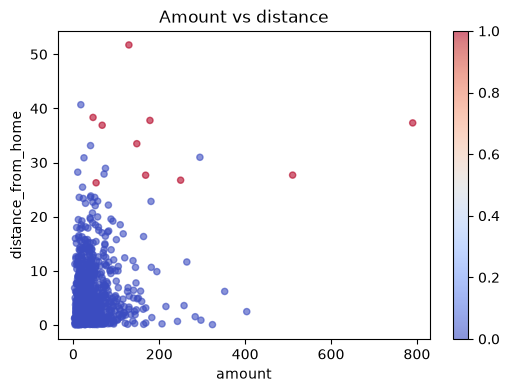

In [19]:
ax = df.plot.scatter(x='amount', y='distance_from_home', c=df['is_fraud'], cmap='coolwarm', figsize=(6,4), alpha=0.6); ax.set_title('Amount vs distance');

### Outlier EDA prompt 9

List top 5 amounts overall.

In [20]:
display(df.nlargest(5, 'amount')[['amount','distance_from_home','is_fraud']].round(2))

,amount,distance_from_home,is_fraud
337,790.20,37.32,1
346,510.55,27.68,1
724,403.70,2.46,0
574,352.30,6.19,0
508,323.82,0.06,0


### Outlier EDA prompt 10

List top 5 distances overall.

In [21]:
display(df.nlargest(5, 'distance_from_home')[['amount','distance_from_home','is_fraud']].round(2))

,amount,distance_from_home,is_fraud
632,129.23,51.72,1
595,17.31,40.68,0
351,45.73,38.33,1
116,178.27,37.78,1
337,790.20,37.32,1


### Outlier EDA prompt 11

Compute fraud rate by merchant category.

In [22]:
rates = df.groupby('merchant_category')['is_fraud'].mean().sort_values(ascending=False); print(rates.head(5).round(4))

merchant_category
online_retail    0.0234
travel           0.0148
restaurant       0.0123
grocery          0.0072
gas              0.0070
Name: is_fraud, dtype: float64


### Outlier EDA prompt 12

Check missing values.

In [23]:
print(df.isna().sum().to_dict())

{'transaction_id': 0, 'timestamp': 0, 'amount': 0, 'merchant_category': 0, 'distance_from_home': 0, 'is_fraud': 0}


### Outlier EDA prompt 13

Histogram of amount.

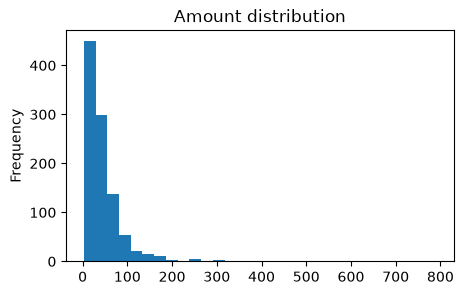

In [24]:
ax = df['amount'].plot(kind='hist', bins=30, figsize=(5,3)); ax.set_title('Amount distribution');

### Outlier EDA prompt 14

Histogram of distance.

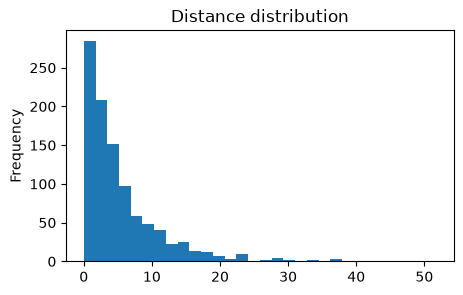

In [25]:
ax = df['distance_from_home'].plot(kind='hist', bins=30, figsize=(5,3)); ax.set_title('Distance distribution');

### Outlier EDA prompt 15

Compare IQR bounds for amount.

In [26]:
lo, hi = iqr_bounds(df['amount']); print({'lower': round(lo,2), 'upper': round(hi,2)})

{'lower': np.float64(-37.81), 'upper': np.float64(111.91)}


### Outlier EDA prompt 16

Count rows below amount lower bound.

In [27]:
lo, hi = iqr_bounds(df['amount']); print(int((df['amount'] < lo).sum()))

0


### Outlier EDA prompt 17

Summarize fraud amount range.

In [28]:
print(df.loc[df['is_fraud']==1, 'amount'].agg(['min','max','mean']).round(2).to_dict())

{'min': 45.73, 'max': 790.2, 'mean': 233.94}


### Outlier EDA prompt 18

Summarize legit amount range.

In [29]:
print(df.loc[df['is_fraud']==0, 'amount'].agg(['min','max','mean']).round(2).to_dict())

{'min': 2.6, 'max': 403.7, 'mean': 43.22}


### Outlier EDA prompt 19

Re-state dataset size.

In [30]:
print({'rows': len(df), 'fraud': int(df['is_fraud'].sum())})

{'rows': 1000, 'fraud': 10}


### Outlier EDA prompt 20

Bridge to imbalance lab.

In [31]:
print('Next: quantify 99:1 imbalance and baseline accuracy trap.')

Next: quantify 99:1 imbalance and baseline accuracy trap.


### Lab 1 quick recap 1

Pause and summarize one takeaway from the previous cell before moving on.

In [32]:
print("Lab 1 recap step 1: completed")

Lab 1 recap step 1: completed


### Lab 1 quick recap 2

Pause and summarize one takeaway from the previous cell before moving on.

In [33]:
print("Lab 1 recap step 2: completed")

Lab 1 recap step 2: completed


### Lab 1 quick recap 3

Pause and summarize one takeaway from the previous cell before moving on.

## Final checkpoint

In [34]:
assert len(df) == 1000
assert int(df["is_fraud"].sum()) == 10
assert amount_outliers == 58
assert distance_outliers == 58
assert abs(legit_amount_mean - 43.22) < 1.0
assert abs(fraud_amount_mean - 233.94) < 5.0
assert abs(max_fraud_distance - 51.72) < 1.0
print("Numbers match — you're good.")



Numbers match — you're good.


## Reflection

Why are there more IQR outliers than fraud cases?